# [Tutorial](https://github.com/biohub/esm/tree/main/cookbook/tutorials): ESMFold2

## **Overview**

ESMFold2 is a structure prediction model that can fold proteins, nucleic acids (RNA and DNA), small-molecule ligands, and complexes containing combinations of these. In this tutorial, we use the `fold_all_atom()` method to predict all-atom structures for three systems that highlight different capabilities:

1. **Protein–nucleic acid complexes**:

    LC11-RNase H1 (a thermostable metagenomic RNase H1) bound to an RNA:DNA hybrid duplex. This example shows how to fold a protein together  with RNA and DNA chains.

2. **Non-canonical amino acids + Covalent modifications**:

    The GLP-1 receptor (GLP1R) bound to semaglutide, a therapeutic peptide with a non-canonical amino acid and a covalently attached lipid linker. This example shows how to include non-canonical residues via [Chemical Component Dictionary (CCD) codes](https://www.wwpdb.org/data/ccd), define a small-molecule ligand from SMILES, and specify an explicit covalent bond between a peptide and a ligand.

3. **Folding with MSAs**:

    We use the example of Ubiquitin to show how to incorporate evolutionary information to improve prediction accuracy.

## **Learning goals**

After completing this tutorial, you will be able to:

- Use the ESM SDK `input_builder` to represent multi-chain biological systems
- Fold protein–RNA–DNA complexes with `fold_all_atom()`
- Include non-canonical amino acids in a peptide via CCD codes
- Define small-molecule ligands from SMILES
- Specify explicit covalent bonds between peptide and ligand atoms
- Pass a multiple sequence alignment (MSA) to improve folding accuracy
- Interpret per-residue (pLDDT) and pairwise (PAE) confidence outputs
- Apply this workflow to your own systems


**Note that each example can be run independently after completing the Setup section**

# **Setup**

In [3]:
#If you are working in colab, uncomment these lines to install dependencies
!pip install esm@git+https://github.com/Biohub/esm.git@main
!pip install py3dmol

  Cloning https://github.com/Biohub/esm.git (to revision main) to /tmp/pip-install-0pw56o8_/esm_115579787088475a95b0b537a48083ef
  Running command git clone --filter=blob:none --quiet https://github.com/Biohub/esm.git /tmp/pip-install-0pw56o8_/esm_115579787088475a95b0b537a48083ef
  Resolved https://github.com/Biohub/esm.git to commit fba1e42a8a0f8df2b7e08611c88807aa32a25d9c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/Biohub/transformers.git (to revision main) to /tmp/pip-install-0pw56o8_/transformers_b776010eb4104252850077d5b502dc11
  Running command git clone --filter=blob:none --quiet https://github.com/Biohub/transformers.git /tmp/pip-install-0pw56o8_/transformers_b776010eb4104252850077d5b502dc11
  Resolved https://github.com/Biohub/transformers.git to commit ef32577f55da19a4989cd7b22e004dc43a4998cb
  Installing build dependencies ... done
  Getting requirements to

In [4]:
from getpass import getpass

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import py3Dmol

from esm.sdk import esmfold2_client
from esm.sdk.api import FoldingConfig
from esm.utils.structure import input_builder

In [5]:
from IPython.display import HTML, display


def plddt_hex(v):
    """Convert pLDDT score to hex color."""
    if v >= 90:
        return "#0053D6"
    if v >= 70:
        return "#65CBF3"
    if v >= 50:
        return "#FFDB13"
    return "#FF7D45"


PLDDT_LEGEND = (
    '<span style="color:#FF7D45;">&#9632;</span> &lt;50 &nbsp;'
    '<span style="color:#FFDB13;">&#9632;</span> 50–70 &nbsp;'
    '<span style="color:#65CBF3;">&#9632;</span> 70–90 &nbsp;'
    '<span style="color:#0053D6;">&#9632;</span> &gt;90'
)


def normalize_plddt(plddt):
    plddt = np.array(plddt)
    return plddt * 100 if plddt.max() <= 1.0 else plddt


def apply_plddt_style(view, plddt, add_hetflag=False):
    view.setStyle({}, {})
    for i, s in enumerate(plddt):
        view.setStyle({"resi": i + 1}, {"cartoon": {"color": plddt_hex(s)}})
    if add_hetflag:
        view.addStyle({"hetflag": True}, {"stick": {}})
    view.zoomTo()


def show_dual_viewer(v1, title1, legend1, v2, title2, legend2):
    l1 = (
        f'<p style="text-align:center; font-size:12px; margin-top:4px;">{legend1}</p>'
        if legend1
        else ""
    )
    l2 = (
        f'<p style="text-align:center; font-size:12px; margin-top:4px;">{legend2}</p>'
        if legend2
        else ""
    )
    display(
        HTML(
            '<div style="display:flex; gap:20px;">'
            f'<div><p style="text-align:center; font-weight:bold;">{title1}</p>'
            + v1._make_html()
            + l1
            + "</div>"
            f'<div><p style="text-align:center; font-weight:bold;">{title2}</p>'
            + v2._make_html()
            + l2
            + "</div>"
            "</div>"
        )
    )


def plot_pae(pae, chains=None, title=None):
    """Plot a PAE matrix with optional per-chain colored bars and legend.

    Args:
        pae: PAE as a numpy array (n x n).
        chains: list of (start, end, label, color) tuples. When provided, colored
            bars are drawn along the top and left axes and a legend is shown.
        title: optional plot title.
    """
    total_len = pae.shape[0]

    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(
        pae, cmap="Greens_r", vmin=0, vmax=30, origin="upper", aspect="equal"
    )

    if chains:
        bar_thickness = total_len * 0.015
        for start, end, label, color in chains:
            ax.add_patch(
                mpatches.Rectangle(
                    (start - 0.5, -bar_thickness - 1),
                    end - start,
                    bar_thickness,
                    facecolor=color,
                    clip_on=False,
                    edgecolor="black",
                    linewidth=0.5,
                )
            )
            ax.add_patch(
                mpatches.Rectangle(
                    (-bar_thickness - 1, start - 0.5),
                    bar_thickness,
                    end - start,
                    facecolor=color,
                    clip_on=False,
                    edgecolor="black",
                    linewidth=0.5,
                )
            )
        for start, *_ in chains[1:]:
            ax.axhline(start - 0.5, color="black", linewidth=1.5)
            ax.axvline(start - 0.5, color="black", linewidth=1.5)
        legend_handles = [
            mpatches.Patch(facecolor=c, edgecolor="black", label=l)
            for _, _, l, c in chains
        ]
        ax.legend(
            handles=legend_handles,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.08),
            ncol=len(chains),
            frameon=True,
            fontsize=10,
            title="Chain",
        )
        ax.set_xlim(-bar_thickness - 2, total_len)
        ax.set_ylim(total_len, -bar_thickness - 2)

    ax.set_xlabel("Scored Residue", fontsize=12)
    ax.set_ylabel("Aligned Residue", fontsize=12)
    if title:
        ax.set_title(title, fontsize=14, fontweight="bold", pad=15)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Expected Position Error (Ångströms)", fontsize=12)
    cbar.set_ticks([0, 5, 10, 15, 20, 25, 30])
    cbar.ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

## Biohub Client

First, we need to set up the Biohub client. Generate an API key on the [Biohub platform](https://biohub.ai) and add it to your account. This API key manages your access to credits and tokens, and the term API key/token is often used interchangeably within documentation.

Please note that your API key is like a password for your account and you should take care to protect it. For this reason it is recommended to frequently create a new API key and delete old, unused ones. It is also recommended to paste the API key directly into an environment variable or use a utility like `getpass` as shown in the example below so keys are not accidentally shared or checked into code repositories.

In [6]:
token = getpass("Biohub token: ")

client = esmfold2_client(
    model="esmfold2-fast-2026-05", url="https://biohub.ai", token=token
)

Biohub token: ··········


# **Folding Configuration**

Configure the folding parameters to control prediction quality and computational cost:

* **num_loops** (default `20`): Number of times the structure is iteratively refined. More loops generally improve accuracy but increase runtime.

* **num_sampling_steps** (default `100`): Number of diffusion sampling steps. Higher values produce more accurate structures but take longer.

* **lm_dropout** (default `0.3`): Dropout probability on LM pair embeddings. When > 0, dropout is applied.

* **lm_mask_pct** (default `0.1` for `esmfold2-fast`, `0.0` for `esmfold2`): Fraction of sequence residues randomly masked before the PLM backbone. Leave unset (`None`) to use the model-dependent default.

* **msa_max_depth** (default `1024`): Number of MSA rows randomly subsampled on each loop. Set to `None` to disable MSA subsampling.

We use a moderate number of loops (10) to balance accuracy and runtime for this example. For more accurate results, especially when modeling flexible ligands or uncertain binding modes, you can increase num_loops at the cost of longer runtimes.

In [10]:
config = FoldingConfig(num_loops=20, num_sampling_steps=100, lm_mask_pct=0.0, include_pae=True)

# **Example 1: RNase H1–RNA/DNA hybrid complex**
Ribonuclease H1 (RNase H1) is an endonuclease that specifically hydrolyzes the RNA strand of an RNA:DNA hybrid. RNase H activity is essential during DNA replication, transcription, and reverse transcription, and is the mechanism of action exploited by gapmer antisense oligonucleotide drugs.

The complex from PDB 4H8K has three biological roles distributed across four chains:

- **LC11-RNase H1 (chains A and B):** a thermostable RNase H1 ortholog from a metagenomic source, expressed and crystallized as a homodimer. We supply it as a single `ProteinInput` with two chain IDs.
- **Substrate RNA (chain C):** the RNA strand that pairs with the DNA template and is cleaved by the enzyme.
- **Substrate DNA (chain D):** the complementary DNA strand of the hybrid duplex.

We will fold all four chains together, replicating the architecture seen in PDB 4H8K.

In [12]:
# Define antibody-antigen complex components

# Heavy chain (VH only)
vh_sequence = (
    "EVQLVESGGGLVKPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLEWVSSISSSSSYIYYADSVKGRFTISRDNAKNSLYLQMNSLRAEDTAVYYCAR"
    "APAAISYYMDVWGKGTTVTVS"
    "G"
)

# Light chain (VL only)
vl_sequence = (
    "DIVMTQSPDSLAVSLGERATINCKSSQSVLYSSNNKNYLAWYQQKPGQPPKLLIYWASTRESGVPDRFSGSGSGTDFTLTISSLQAEDVAVYYCQQYY"
    "STPALTFGGGTKVEIK"
)

# Antigen (HA ectodomain, linker trimmed, ends at KREEISGVR)
antigen_sequence = (
    "DQICIGYHANNSTEQVDTIMEKNVTVTHAQDILEKKHNGKLCDLDGVKPLILRDCSVAGWLLGNPMCDEFINVPEWSYIVEKANPVNDLCFPGDFNDYE"
    "ELKHLLSRINHFEKIQIIPKSSWSSHEASLGVSSACPYQGKSSFFRNVVWLIKKNSTYPTIKRSYNNTNQEDLLVLWGIHHPNDAAEQTKLYQNPTTYIS"
    "VGTSTLNQRLVPRIATRSKVNGQSGRMEFFWTILKPNDAINFESNGNFIAPEYAYKIVKKGDSTIMKSELEYGNCNTKCQTPMGAINSSMPFHNIHPLTIG"
    "ECPKYVKSNRLVLATGLRNSPQRERGLFGAIAGFIEGGWQGMVDGWYGYHHSNEQGSGYAADKESTQKAIDGVTNKVNSIIDKMNTQFEAVGREFNNLERR"
    "IENLNKKMEDGFLDVWTYNAELLVLMENERTLDFHDSNVKNLYDKVRLQLRDNAKELGNGCFEFYHKCDNECMESVRNGTYDYPQYSEEARLKREEISGVR"
)

# Config with max allowed values
config = FoldingConfig(num_loops=20, num_sampling_steps=100, lm_mask_pct=0.0, include_pae=True)

# Build inputs: heavy chain as A, light chain as B, antigen as C
antibody_heavy = input_builder.ProteinInput(id="A", sequence=vh_sequence)
antibody_light = input_builder.ProteinInput(id="B", sequence=vl_sequence)
antigen = input_builder.ProteinInput(id="C", sequence=antigen_sequence)

# Create the complex input
antibody_antigen_input = input_builder.StructurePredictionInput(
    sequences=[antibody_heavy, antibody_light, antigen]
)

# Fold and check for errors
antibody_antigen_structure = client.fold_all_atom(antibody_antigen_input, config=config)

if hasattr(antibody_antigen_structure, 'complex'):
    with open("antibody_antigen_complex.cif", "w") as f:
        f.write(antibody_antigen_structure.complex.to_mmcif())
    print("Structure saved successfully to antibody_antigen_complex.cif")
else:
    print("Folding failed. Error details:")
    print(type(antibody_antigen_structure))
    print(antibody_antigen_structure)

Structure saved successfully to antibody_antigen_complex.cif


## **Visualize the Complex**

We will visualize the complex in two ways:
1. Each chain colored separately (the two RNase H1 protomers, the RNA strand, and the DNA strand)
2. With residues colored by per-residue confidence score (pLDDT), which reflects how confident the model is in the position of each residue.

**Tip**: pLDDT scores reflect per-residue confidence: very high (>90, dark blue), high (70–90, light blue), low (50–70, yellow), very low (<50, orange). RNA/DNA termini and flexible loops typically score lower, which is expected.

In [13]:
ab_cif = open("antibody_antigen_complex.cif").read()
ab_plddt = normalize_plddt(antibody_antigen_structure.plddt.cpu().numpy())

v1 = py3Dmol.view(width=500, height=400)
v1.addModel(ab_cif, "mmcif")
v1.setStyle({"chain": "A"}, {"cartoon": {"color": "#4A90E2"}})  # VH - blue
v1.setStyle({"chain": "B"}, {"cartoon": {"color": "#E24A90"}})  # VL - pink
v1.setStyle({"chain": "C"}, {"cartoon": {"color": "#F5A623"}})  # Antigen - orange
v1.zoomTo()

v2 = py3Dmol.view(width=500, height=400)
v2.addModel(ab_cif, "mmcif")
apply_plddt_style(v2, ab_plddt)

ab_legend = (
    '<span style="color:#4A90E2;">&#9632;</span> VH (A) &nbsp;'
    '<span style="color:#E24A90;">&#9632;</span> VL (B) &nbsp;'
    '<span style="color:#F5A623;">&#9632;</span> HA Antigen (C)'
)

show_dual_viewer(
    v1,
    "Antibody–Antigen Complex",
    ab_legend,
    v2,
    "Confidence (pLDDT)",
    PLDDT_LEGEND,
)

In [14]:
from google.colab import files
files.download("antibody_antigen_complex.cif")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

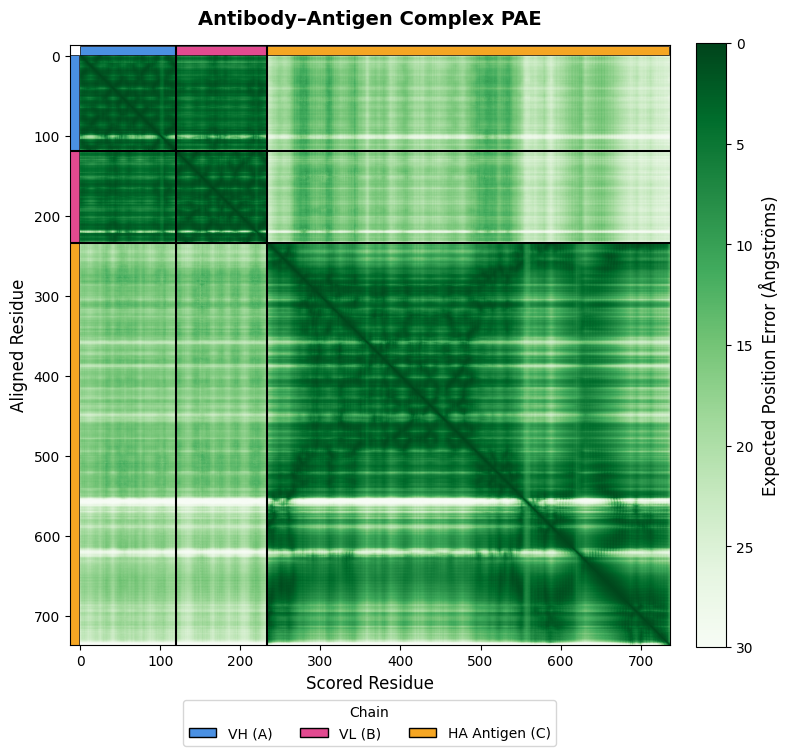

In [15]:
pae = antibody_antigen_structure.pae.cpu().numpy()

len_vh = len(vh_sequence)
len_vl = len(vl_sequence)
len_antigen = len(antigen_sequence)

plot_pae(
    pae,
    chains=[
        (0, len_vh, "VH (A)", "#4A90E2"),
        (len_vh, len_vh + len_vl, "VL (B)", "#E24A90"),
        (len_vh + len_vl, len_vh + len_vl + len_antigen, "HA Antigen (C)", "#F5A623"),
    ],
    title="Antibody–Antigen Complex PAE",
)

# **Example 2: Semaglutide + GLP1 receptor**

In [ ]:
# Human GLP1R sequence (UniProt P43220)
# This construct includes N-terminal FLAG tag, TEV cleavage site, and C-terminal His-tag
receptor_sequence = (
    "MKTIIALSYIFCLVFADYKDDDDLEVLFQGPARPQGATVSLWETVQKWREYRRQCQRSLTEDPPPATDLFCNRTFDEYAC"
    "WPDGEPGSFVNVSCPWYLPWASSVPQGHVYRFCTAEGLWLQKDNSSLPWRDLSECEESKRGERSSPEEQLLFLYIIYTVG"
    "YALSFSALVIASAILLGFRHLHCTRNYIHLNLFASFILRALSVFIKDAALKWMYSTAAQQHQWDGLLSYQDSLSCRLVFL"
    "LMQYCVAANYYWLLVEGVYLYTLLAFSVFSEQWIFRLYVSIGWGVPLLFVVPWGIVKYLYEDEGCWTRNSNMNYWLIIRL"
    "PILFAIGVNFLIFVRVICIVVSKLKANLMCKTDIKCRLAKSTLTLIPLLGTHEVIFAFVMDEHARGTLRFIKLFTELSFT"
    "SFQGLMVAILYCFVNNEVQLEFRKSWERWRLEHLHIQRDSSMKPLKCPTSSLSSGATAGSSMYTATCQASCSPAGLEVLF"
    "QGPHHHHHHH"
)

receptor = input_builder.ProteinInput(id="A", sequence=receptor_sequence)

## **Define the Semaglutide Peptide**

Now we define the semaglutide peptide (chain B) with:

* **AIB substitution at position 2**: α-aminoisobutyric acid (AIB) is a non-natural amino acid that increases peptide stability by restricting backbone flexibility and reducing proteolytic degradation. This modification is commonly used in therapeutic peptides to improve their pharmacokinetic properties.

* **Lysine as the attachment site**: We identify the lysine residue that will form the covalent bond with the lipid linker.

In [ ]:
# Semaglutide peptide sequence
peptide_sequence = "HAEGTFTSDVSSYLEGQAAKEFIAWLVRGRG"

# AIB substitution (0-indexed)
aib_position = 1

peptide = input_builder.ProteinInput(
    id="B",
    sequence=peptide_sequence,
    modifications=[input_builder.Modification(position=aib_position, ccd="AIB")],
)

lys_idx = peptide_sequence.index("K")  # residue index in peptide (0-based)
print("Lys at residue index:", lys_idx)

Lys at residue index: 19


## **Define the Lipid Linker (SMILES)**

We define a lipid-like linker using SMILES notation. The SMILES is written so that the attachment carbonyl carbon is the first atom, making atom indexing simple.

In [ ]:
def get_protractor_smiles() -> str:
    # "Protractor" refers to Novo Nordisk's fatty acid linker technology used in semaglutide.
    # This SMILES is a representative structure inspired by semaglutide's linker design,
    # not the exact compound. For the precise semaglutide structure, see PDB 7KI0 or the FDA label.
    # First atom (index 0) is the carbonyl carbon used for attachment to the peptide.
    return "C(=O)(CCOCCOCC(=O)NCCOCCOCCNCC(=O)N[C@@H](CCC(=O)NCCCCCCCCCCCCCCCCCC(=O)O)C(=O)O)"


ligand = input_builder.LigandInput(id="C", ccd=None, smiles=get_protractor_smiles())

## **Fold the Complex with Covalent Bond**
Now we fold human GLP1R + semaglutide peptide + lipid linker together.

## **Understanding Atom Indices for Covalent Bonds**

To specify a covalent bond, we need to identify the exact atoms that connect:

**Peptide side (chain B, lysine residue):**
- We use `atom_idx1=8`, Within a lysine residue, NZ is typically the 9th atom (index 8 in 0-based ordering). Depending on the input representation, you may need to map this to the correct atom index within the full structure.

- For any residue, this atom ordering corresponds to the `pdbx_ordinal` section of the Lysine cif file found [here](https://www.rcsb.org/ligand/LYS).

```
Lysine atom order (0-indexed):
    0: N  (backbone nitrogen)
    1: CA (alpha carbon)
    2: C  (carbonyl carbon)
    3: O  (carbonyl oxygen)
    4: CB (beta carbon)
    5: CG (gamma carbon)
    6: CD (delta carbon)
    7: CE (epsilon carbon)
    8: NZ (zeta nitrogen) ← attachment point
```

**Ligand side (chain C, linker):**
- We use `atom_idx2=0`, which is the **carbonyl carbon** of the linker
- Our SMILES string starts with `C(=O)...`, making the first carbon atom index 0

**Tip**: To determine atom indices for your own systems, you can:
- **For residues**: Use the CIF files to determine atom indexes.  
- **For SMILES**, atom indices are the same as string indices.

In [ ]:
bond = input_builder.CovalentBond(
    chain_id1="B", res_idx1=lys_idx, atom_idx1=8, chain_id2="C", res_idx2=0, atom_idx2=0
)

complex_inputs = input_builder.StructurePredictionInput(
    sequences=[receptor, peptide, ligand], covalent_bonds=[bond]
)

complex_structure = client.fold_all_atom(complex_inputs, config=config)

with open("glp1r_semaglutide.cif", "w") as f:
    f.write(complex_structure.complex.to_mmcif())

## **Visualize the Complex**

In [ ]:
cif_data = open("glp1r_semaglutide.cif").read()
plddt = normalize_plddt(complex_structure.plddt.cpu().numpy())

v1 = py3Dmol.view(width=500, height=400)
v1.addModel(cif_data, "mmcif")
v1.setStyle({"chain": "A"}, {"cartoon": {"color": "#2166ac"}})
v1.setStyle({"chain": "B"}, {"cartoon": {"color": "#f4a9c4"}})
v1.addStyle({"hetflag": True}, {"stick": {"color": "#e6550d"}})
# Highlight the lysine on semaglutide that anchors the protractor linker
v1.addStyle({"chain": "B", "resn": "LYS"}, {"stick": {}})
v1.zoomTo()

v2 = py3Dmol.view(width=500, height=400)
v2.addModel(cif_data, "mmcif")
apply_plddt_style(v2, plddt, add_hetflag=True)
v2.addStyle({"chain": "B", "resn": "LYS"}, {"stick": {}})

chain_legend = (
    '<span style="color:#2166ac;">&#9632;</span> Receptor &nbsp;'
    '<span style="color:#f4a9c4;">&#9632;</span> Peptide &nbsp;'
    '<span style="color:#e6550d;">&#9632;</span> Protractor'
)
show_dual_viewer(
    v1, "Chain identity", chain_legend, v2, "Confidence (pLDDT)", PLDDT_LEGEND
)

## **Predicted Aligned Error (pAE)**

The pAE matrix shows the expected position error (Ångströms) between each pair of residues. Regions of high confidence are dark green while low confidence are pale green. For complexes, the off-diagonal blocks capture inter-chain confidence. This can be useful when scoring a designed interface, for example.

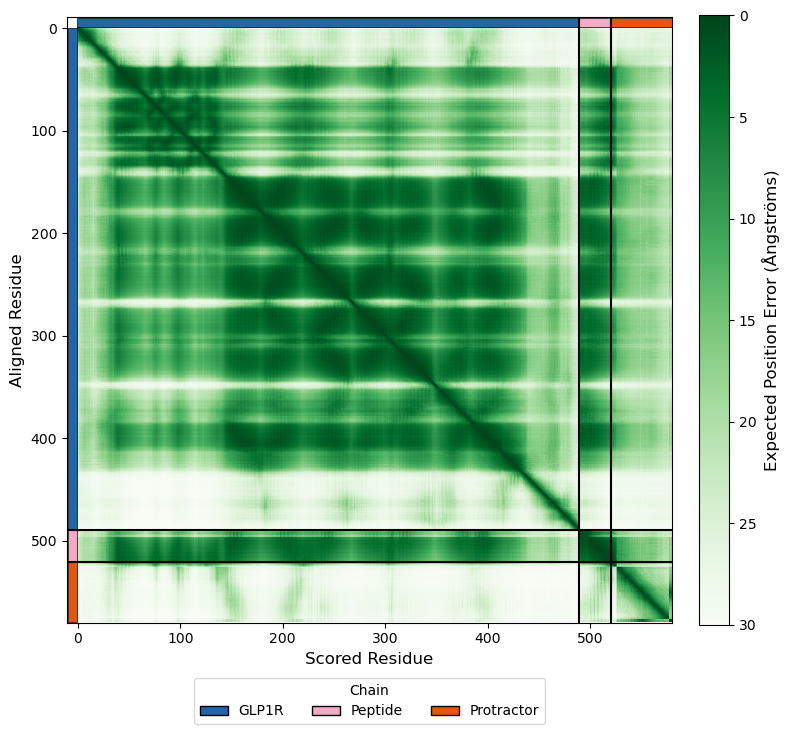

In [ ]:
pae = complex_structure.pae.cpu().numpy()
len_receptor = len(receptor_sequence)
len_peptide = len(peptide_sequence)

plot_pae(
    pae,
    chains=[
        (0, len_receptor, "GLP1R", "#2166ac"),
        (len_receptor, len_receptor + len_peptide, "Peptide", "#f4a9c4"),
        (len_receptor + len_peptide, pae.shape[0], "Protractor", "#e6550d"),
    ],
)

# **Example 3: MSA-Guided Folding of Ubiquitin**

Thus far we have relied on single-sequence folding, which trades accuracy for speed. ESMFold2 can also be called using Multiple Sequence Alignments (MSAs), which provide evolutionary context that can significantly improve folding accuracy. MSAs reveal how sequences have evolved across related species and proteins, helping the model identify structurally important residues and coevolutionary constraints.

In this example, we fold **ubiquitin**, a small 76-residue regulatory protein found in virtually all eukaryotic organisms. We'll use a real MSA from a ColabFold MMseqs2 search.

MSAs are particularly helpful for:
- Proteins with many homologs
- Identifying conserved structural features
- Improving accuracy in uncertain regions
- Resolving ambiguous conformations

## **Visualize Ubiquitin Structure**

In [ ]:
# download the MSA
!wget -q "https://drive.google.com/uc?export=download&id=1la9UUK_FnFQFR9VB35DIB797d87Zwm0b" -O ubiquitin.a3m

In [ ]:
from esm.utils.msa import MSA
from esm.utils.structure.input_builder import ProteinInput, StructurePredictionInput

ubiquitin_sequence = (
    "MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG"
)

msa = MSA.from_a3m(path="ubiquitin.a3m", remove_insertions=True, max_sequences=1000)
print(f"MSA depth: {msa.depth} sequences, length: {msa.seqlen} residues")

# Sanity check — first MSA seq should match the query
print("First MSA seq matches query:", msa.sequences[0] == ubiquitin_sequence)
print("First MSA seq:", repr(msa.sequences[0][:80]))
print("Query:        ", repr(ubiquitin_sequence))

fold_result = client.fold_all_atom(
    StructurePredictionInput(
        sequences=[ProteinInput(id="A", sequence=ubiquitin_sequence, msa=msa)]
    )
)

print(f"\npTM: {fold_result.ptm:.3f}")
print(f"Average pLDDT: {fold_result.plddt.mean().item():.1f}")

with open("ubiquitin_with_msa.cif", "w") as f:
    f.write(fold_result.complex.to_mmcif())

MSA depth: 1000 sequences, length: 76 residues
First MSA seq matches query: True
First MSA seq: 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG'
Query:         'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG'

pTM: 0.814
Average pLDDT: 0.9


In [ ]:
cif_data = open("ubiquitin_with_msa.cif").read()
plddt = normalize_plddt(fold_result.plddt.cpu().numpy())

v1 = py3Dmol.view(width=500, height=400)
v1.addModel(cif_data, "mmcif")
v1.setStyle({}, {"cartoon": {"color": "#4A90E2"}})
v1.zoomTo()

v2 = py3Dmol.view(width=500, height=400)
v2.addModel(cif_data, "mmcif")
apply_plddt_style(v2, plddt)
v2.zoomTo()

show_dual_viewer(
    v1, "Ubiquitin (cartoon)", None, v2, "Confidence (pLDDT)", PLDDT_LEGEND
)

Alternative MSA Methods:

- `MSA.from_a3m(path="/path/to/file.a3m")`: Load MSA from an A3M format file. Use remove_insertions=True to remove lowercase insertion characters, and max_sequences to limit MSA depth.
- `MSA.from_sequences(sequences)`: Create an MSA programmatically from a list of aligned sequences. The query sequence should always be first.

Deeper MSAs (more sequences) provide more evolutionary information but increase computation time.